In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, confusion_matrix,  ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns



In [9]:
iris_df = pd.read_csv("irisdatasets.csv") 
iris_df = iris_df.replace(["", " ", "NA", "N/A", "null", "None", "?"], pd.NA)

print("Shape:", iris_df.shape)
print("\nMissing values per column:")
print(iris_df.isna().sum())
print("\nMissing percentage:")
print((iris_df.isna().mean() * 100).round(2))

print("\nData types:")
print(iris_df.dtypes)

print("\nDescribe:")
display(iris_df.describe(include="all"))




Shape: (150, 5)

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Missing percentage:
sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Describe:


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


Before Outlier Removal:


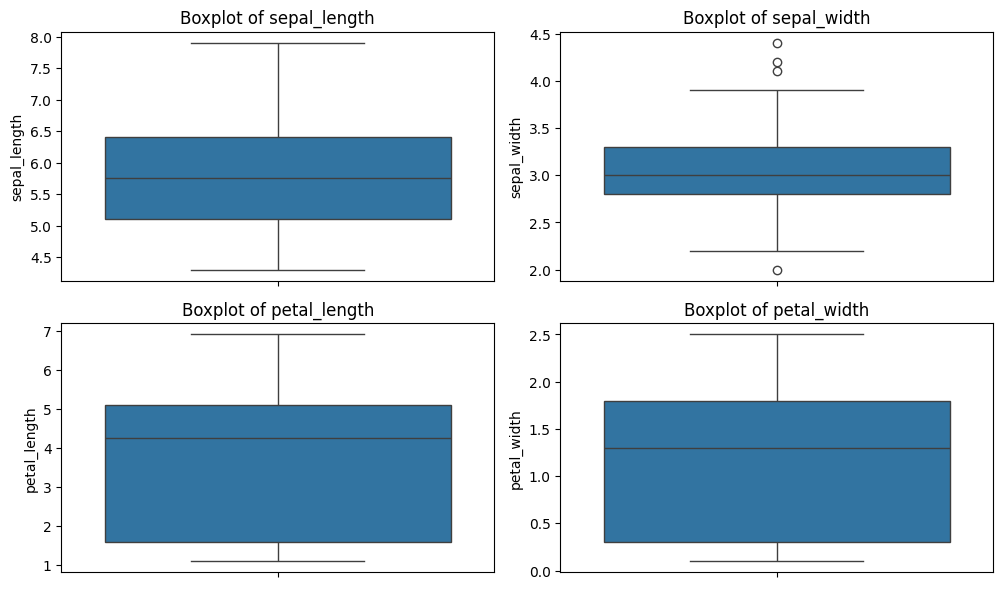


Train shape after outlier removal: (116, 4)
Test shape unchanged: (30, 4)

After Outlier Removal:


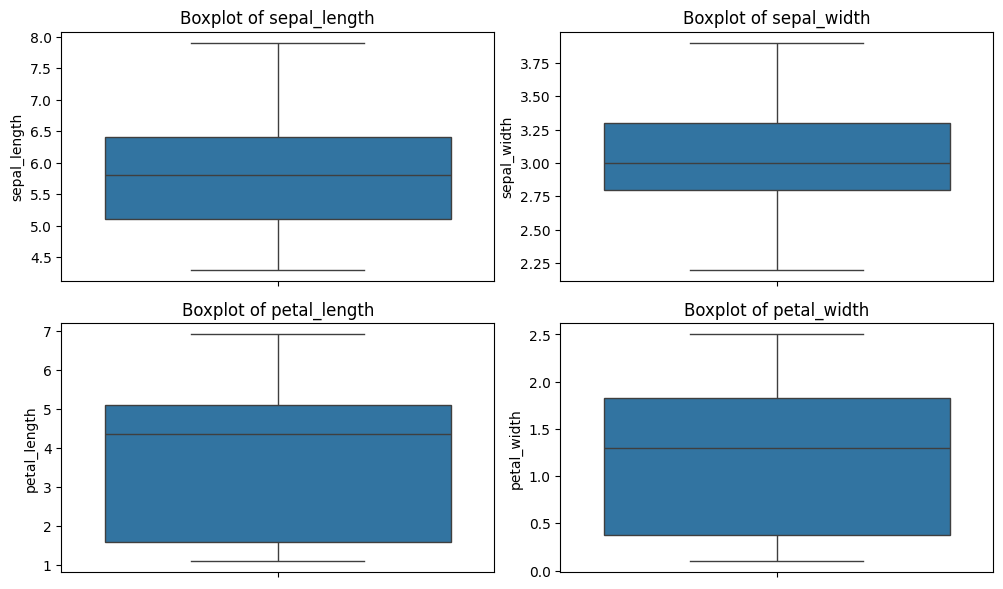


Missing after imputation (train):
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

Missing after imputation (test):
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64


In [3]:
target_col = "species"
X = iris_df.drop(target_col, axis=1)
y = iris_df[target_col]

mask = y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Before Outlier Removal:")
plt.figure(figsize=(10, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=X_train[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

def remove_outliers_iqr(df, cols, k=1.5):
    keep = pd.Series(True, index=df.index)
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - k * iqr
        high = q3 + k * iqr
        keep &= df[col].between(low, high) | df[col].isna()  
    return keep

train_keep = remove_outliers_iqr(X_train, num_cols)
X_train = X_train.loc[train_keep].reset_index(drop=True)
y_train = y_train.loc[train_keep].reset_index(drop=True)

print("\nTrain shape after outlier removal:", X_train.shape)
print("Test shape unchanged:", X_test.shape)

cat_cols = [c for c in X_train.columns if c not in num_cols]

num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

print("\nAfter Outlier Removal:")

plt.figure(figsize=(10, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=X_train[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])


print("\nMissing after imputation (train):")
print(X_train.isna().sum())
print("\nMissing after imputation (test):")
print(X_test.isna().sum())


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [5]:
kernels = ["linear", "poly", "rbf", "sigmoid"]
c_values = [0.1 , 0.2, 0.3]

results = []

for kernel in kernels:
    for i, c in enumerate(c_values, start=1):
        c_label = f"c{i}"
        model = SVC(kernel=kernel, C=c, gamma=0.5, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        results.append({
            "Type of Kernel": kernel.capitalize(),
            "c_label": c_label,
            "C": c,
            "PrecisionResult": round(precision, 4)
        })

df_results = pd.DataFrame(results)
df_results

,Type of Kernel,c_label,C,PrecisionResult
0,Linear,c1,0.1,0.9333
1,Linear,c2,0.2,0.9697
2,Linear,c3,0.3,0.9697
3,Poly,c1,0.1,0.9048
4,Poly,c2,0.2,0.9231
5,Poly,c3,0.3,0.9231
6,Rbf,c1,0.1,0.9024
7,Rbf,c2,0.2,0.9333
8,Rbf,c3,0.3,0.9697
9,Sigmoid,c1,0.1,0.8750


In [6]:
result_table = df_results.pivot(index="Type of Kernel", columns="c_label", values="PrecisionResult")
result_table = result_table.reindex(index=["Linear", "Poly", "Rbf", "Sigmoid"])
result_table = result_table[["c1", "c2", "c3"]]
for i, c in enumerate(c_values):
    print(f"c{i+1} = {c}")
result_table

c1 = 0.1
c2 = 0.2
c3 = 0.3


c_label,c1,c2,c3
Type of Kernel,,,
Linear,0.9333,0.9697,0.9697
Poly,0.9048,0.9231,0.9231
Rbf,0.9024,0.9333,0.9697
Sigmoid,0.8750,0.8750,0.8750


d:\Python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


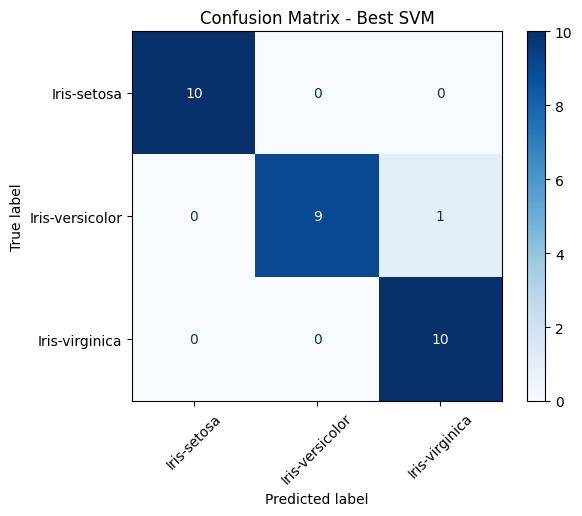

Best SVM: kernel = linear, C= 0.2, precision= 0.9697
Predicted Class:  Iris-setosa
Predicted Class:  Iris-setosa


In [ ]:
best_row = df_results.sort_values(by="PrecisionResult", ascending=False).iloc[0]
best_kernel = best_row["Type of Kernel"].lower()
best_c = best_row["C"]

best_model = SVC(kernel=best_kernel, C=best_c, gamma=0.5, random_state=42)
best_model.fit(X_train_scaled, y_train)
best_pred = best_model.predict(X_test_scaled)

#arbitrary
new_X = [[5.1, 3.5, 1.4, 0.2], 
         [5, 2.5, 1.9, 0.1]] 
new_X_scaled = scaler.transform(new_X)
predictions = best_model.predict(new_X_scaled)



# Confusion matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Best SVM")
plt.show()


print(f"Best SVM: kernel = {best_kernel}, C= {best_c}, precision= {best_row['PrecisionResult']}")
for prediction in predictions:
    print("Predicted Class: ", prediction)
